In [26]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.fft import fft, ifft
from os import listdir
from scipy.special import gammaln


# The Poisson-Influenced K-Means Algorithm

Single photon detection using transition edge sensors (TES).
Algorithm used for TES trace classification.

Based on :

- [1] ‘The Poisson-Influenced K-Means Algorithm « The Mathematica Journal’. 
  https://www.mathematica-journal.com/2016/04/25/the-poisson-influenced-k-means-algorithm/.

- [2] Z. H. Levine et al., ‘Algorithm for finding clusters with a known distribution 
  and its application to photon-number resolution using a superconducting transition-edge sensor’, 
  J. Opt. Soc. Am. B, vol. 29, no. 8, p. 2066, Aug. 2012, doi: 10.1364/JOSAB.29.002066.


In [27]:
config = {
    "iNPhoton" : None, # index of the dataset to read (assuming that multiple datasets are stored in the same location)
    "iDataSet" : None, # list of indices of parts of the dataset to read (assuming that datasets are split over multiple files)
    "nTime" : None, # number of time points to keep after filtration
    "mSample" : None, # maximum number of traces to randomly sample when outputting samples
    "nDatUse" : None, # maximum number of traces to read in (if this is equal to 0, we use all of the traces)
    "backgroundReject" : False, # Boolean, true if PIKA should reject response waveforms with background radiation
    "peakvalcut" : None, # voltage cutoff for background rejection
    "peakPosCut" : None, # peak location cutoff for background rejection
    "peakNumCut" : None, # cutoff for number of peaks for background rejection
    "nCool" : 2, # number of optimizing rounds to perform
    "nGreedy" : 2, # number of rounds that should be run with the greedy algorithm
    "coolConst" : 1, # cooling constant for simulated annealing
    "tAnneal" : 0.02, # starting annealing temperature
    "probDistName" : None, # name of the probability distribution
    "nSigma" : 1, # number of standard deviations from the mean of the probability distribution to generate
    "binFract" : None, # histogram bin size (fraction of a photon number)
    "outputImageSize" : None, # default graphics size for output
    "nPhotonAvgList" : [1,2,3], # list of (close together) mean photon numbers with which to run PIKA on the dataset
    "partialFilePath" : None, # directory and the beginning of the name of the data files, without the iNPhoton or iDataSet markers
    "fileExt" : None, #  file extension of the data files (without the iDataSet marker)
    "pikaInput" : None, # number of samples per trace
    'files' : {
        'dataset'                : "Oxford",
        'path_save'              : 'Autoencoder Log/',
        'input_dimension'        : 496
    }
}

In [28]:
class PIKA():
    def __init__(self): 
        pass


    def readAndFilterData(self, config):
        """
        TODO : include Hann filter (numpy has modules for this)
        """
    
        def applyFiltershort(x, filtershort):
            ft = fft(x)
            nFT = len(ft)
            ftshort = np.concatenate((ft[:nFT//4], [0], ft[(3*nFT//4)+2:]))
            ftFiltered = ftshort * filtershort
            result = ifft(ftFiltered)
            return np.real(result) / 2

        size = config['files']['input_dimension']
        folder = f"Datasets/{config['files']['dataset']}"
        files = listdir(folder)

        data = np.concatenate([np.fromfile(f"{folder}/{file_name}", dtype=np.float16).reshape((-1,size)) for file_name in files])

        window = np.hanning(size/2)

        return data




    def optionallyRejectBackgroundTraces(self, dataset, config):
        """
        TODO : Make filter to reject background traces
        """

        def getIObsKeep(datPeakNum, iObsDrop, datPeakNumCut):
            mask = datPeakNum < datPeakNumCut
            iobsKeepA = np.setdiff1d(np.where(mask)[0], iObsDrop)
            return iobsKeepA
    
        if config['backgroundReject']:
            pass
            #iObsKeep = getIObsKeep(dataset, config['peakPosCut'], config['peakValcut'], config['peakNumCut'])
            #iObsDrop = np.setdiff1d(np.arange(len(dataset)), iObsKeep)

            #data = data[iObsKeep]
            #iObsDrop = None
            #iObsKeep = None

        nObs = len(dataset)
        print(f"PIKA: nObs {nObs} traces selected")

        return dataset


    def findDotProductEffectivePhotonNumbers(self, dataset, config):
        meanTrace = np.mean(dataset, axis = 0)
        nPhotonEff = config['nPhotonAvgList'][0] * np.sum(meanTrace * dataset, axis=1) / np.sum(meanTrace*meanTrace)
        
        plt.figure(0)
        plt.title("Initial mean traces")
        plt.plot(meanTrace, label="meanTrace")
        plt.figure(1)
        plt.title("Initial effective photon number based on dot product alg.")
        plt.hist(nPhotonEff, bins=500)

        return nPhotonEff, meanTrace



    def createInitialClusters(self, nPhotonAvg, nPhotonEff, dataset, config):

        def groupProbability(dat, nPhotonAvg, nPhotonEff, nSigma):

            def poisson(mu, nSigma):
                sigma = np.sqrt(mu)
                tab = []

                lower_limit = int(np.floor(mu - sigma * nSigma))
                upper_limit = int(np.ceil(mu + sigma * nSigma) + 1) 
                
                for n in range(lower_limit, upper_limit):
                    prob = (np.exp(-mu) * mu**n) / np.math.factorial(n)
                    tab.append((n, prob))
                
                total_prob = sum(prob for _, prob in tab)
                return [(n, prob / total_prob) for n, prob in tab]

            def groupProb(dat, prob, nPhotonEff):

                def boundList(lst, minimum, maximum):
                    return [min(max(item, minimum), maximum) for item in lst]

                nPhotonEffSortIndex = np.argsort(nPhotonEff)
                nPhoton, probList = zip(*prob)
                nObs = len(dat)
                probCum = np.cumsum(probList)
                probCum = np.insert(probCum, 0, 0) / probCum[-1]

                probIndexStart = boundList(((nObs * probCum)[:-1] + 1).astype(int), 1, nObs + 1)
                probIndexStop = boundList(((nObs * probCum)[1:]).astype(int), 0 , nObs)

                #keep = probIndexStart <= probIndexStop
    
                nPhotonUse = np.array(nPhoton)#[keep]

                probIndexStartUse = np.array(probIndexStart)#[keep]
                probIndexStopUse = np.array(probIndexStop)#[keep]
        
                nClust = len(probIndexStartUse)
                iObsOfClust = [nPhotonEffSortIndex[probIndexStartUse[iClust]-1:probIndexStopUse[iClust]] for iClust in range(nClust)]
                clustMeanTrace = [np.mean(dat[iObsOfClust[iClust]], axis = 0) for iClust in range(nClust)]

                return nPhotonUse, iObsOfClust, clustMeanTrace


            prob = poisson(nPhotonAvg, nSigma)
            nPhotonUse, iObsOfClust, clustMeanTrace = groupProb(dat, prob, nPhotonEff)

            return prob, nPhotonUse, iObsOfClust, clustMeanTrace


        prob, nPhotonOfClust, iObsOfClust, clustMeanTrace = groupProbability(dataset, nPhotonAvg, nPhotonEff, config['nSigma'])
        nClust = len(clustMeanTrace)

        plt.figure(2)
        plt.title("Mean trace for each cluster in createInitialClusters")
        pl = [plt.plot(clusterTrace) for clusterTrace in clustMeanTrace]
        
        return prob, nPhotonOfClust, iObsOfClust, clustMeanTrace, nClust
    


    def findInitialObjectiveFunction(self, dat, iObsOfClust, clustMeanTrace, nPhotonOfClust, nPhotonAvg, iNPhotonAvgList, nClust):

        def getSqDevOfClust(dat, iObsOfClust, clustMeanTrace):

            def getSqDevInClust(datInClust, meanTraceInClust):
                sqDev = np.sum([(dat - meanTraceInClust) ** 2 for dat in datInClust]) / len(datInClust[0])

                return sqDev

            sqDevOfClust = []
            for iClust, meanTrace in enumerate(clustMeanTrace):
                obsIndices = iObsOfClust[iClust]
                sqDev = getSqDevInClust(dat[obsIndices], meanTrace)
                sqDevOfClust.append(sqDev)

            return sqDevOfClust

        def probComboLogLikelihood(nList, freqList, mu):

            def poissonLogLikelihood(nList, freqList, mu):
                logLikelihood = -mu * np.sum(freqList) + np.dot(nList, np.log(mu)) - np.sum(freqList * gammaln(nList + 1))
                return logLikelihood

            def comboLogLikelihood(freqList):
                logLikelihood = gammaln(np.sum(freqList) + 1) - np.sum(gammaln(np.array(freqList) + 1))
                return logLikelihood

            poissonLogLikelihood = poissonLogLikelihood(nList, freqList, mu)
            comboLogLikelihood = comboLogLikelihood(freqList)
            
            logLikelihood = poissonLogLikelihood + comboLogLikelihood
            return logLikelihood

        def getObjFtn(sqDevOfClust, sigmaObjFtn, logLikeProb):
            objFtn = np.sum(sqDevOfClust / (2 * sigmaObjFtn**2)) - logLikeProb
            return objFtn



        sqDevOfClust = getSqDevOfClust(dat, iObsOfClust, clustMeanTrace)
        nOfClust = [len(obsIndices) for obsIndices in iObsOfClust]
        logLikeProb = probComboLogLikelihood(nPhotonOfClust, nOfClust, nPhotonAvg)

        nObs = len(dat)
        sigmaObjFtn = np.sqrt(np.sum(sqDevOfClust) / nObs)

        print(iNPhotonAvgList, "PIKA: sigmaObjFtn ", sigmaObjFtn)
        sigmaObjFtn = np.full(nClust, sigmaObjFtn)

        objFtn = getObjFtn(sqDevOfClust, sigmaObjFtn, logLikeProb)
        print(iNPhotonAvgList, "Initial objective function: ", objFtn)

        return objFtn, nOfClust, sqDevOfClust, logLikeProb, sigmaObjFtn




    def prepareOptimizationLoop(self, iObsOfClust, dat, iNPhotonAvgList, nClust):
        """
        TODO : Can optimize and not sure if the output is good considering rest.
        Need to verify what the article means by acceptable clusters
        """
        def getIClustOfObs(iObsOfClust):
            iclustOfObs = np.array([])
            for iClust in range(nClust):
                iclustOfObs = np.append(iclustOfObs, iClust * np.ones(len(iObsOfClust[iClust]), dtype=int))
            return iclustOfObs

        if any(np.sort(np.concatenate(iObsOfClust)) != np.arange(len(dat))):
            print(iNPhotonAvgList, "PIKA: WARNING: iObsOfClust does not map each observation to a cluster")

        iclustOfObs = getIClustOfObs(iObsOfClust)
        if np.min(iclustOfObs) <= 0:
            print(iNPhotonAvgList, "PIKA: WARNING: iclustOfObs does not map each observation to a cluster")

        neighborofClust = list(zip(range(nClust - 1), range(nClust + 1)))
        neighborofClust[0] = np.delete(neighborofClust[0], 0)
        neighborofClust[-1] = np.delete(neighborofClust[-1], -1)

        kMove = 0
        nObs = len(iObsOfClust)
        birthOfclust = np.zeros(nClust)
        birthOfObsClust = np.full((nObs, nClust), -1)
        sqDevOfObsClust = birthOfObsClust

        return kMove, birthOfclust, birthOfObsClust, sqDevOfObsClust, iclustOfObs, neighborofClust



    
    def prepareSubLoop(self, nObs):
        iobsAll = np.random.permutation(np.arange(nObs))
        return iobsAll
    



    #def getClusterAndNeighbors(self, iObs, iclustOfObs, nOfClust, neighborofClust):
    #    iClust = int(iclustOfObs[iObs])
    #    if nOfClust[iClust] <= 1:
    #        continue

    #    neighbor = neighborofClust[iClust]
    #    jClust = neighbor[np.random.randint(np.arange(len(neighbor)))]
    #    return jClust, iClust, neighbor


    def updateRelevantDeviations(self, birthOfObsClust, birthOfclust, iObs, iClust, dat, clustMeanTrace, sqDevOfObsClust, jClust, kMove):

        def meanSquare(x):
            return np.dot(x, x) / len(x)

        if birthOfObsClust[iObs, iClust] < birthOfclust[iClust]:
            sqDevOfObsClust[iObs, iClust] = meanSquare(dat[iObs] - clustMeanTrace[iClust])
            birthOfObsClust[iObs, iClust] = kMove

        if birthOfObsClust[iObs, jClust] < birthOfclust[jClust]:
            sqDevOfObsClust[iObs, jClust] = meanSquare(dat[iObs] - clustMeanTrace[jClust])
            birthOfObsClust[iObs, jClust] = kMove

        return sqDevOfObsClust, birthOfObsClust




    def findChangeInObjectiveFunction(self, iObs, iClust, jClust, sqDevOfObsClust, nOfClust, nPhotonAvg, sigmaObjFtn, nPhotonOfClust):

        def deltaKMeansAdd(freq, meanSquareDiff):
            return (freq / (freq + 1)) * meanSquareDiff

        def deltaKMeansDel(freq, meanSquareDiff):
            return (freq / (freq - 1)) * meanSquareDiff

        def deltaPoissonUp(nDel, freqAdd, freqDel, mu):
            return np.log(mu * freqDel / ((nDel + 1) * (freqAdd + 1)))

        def deltaPoissonDn(nDel, freqAdd, freqDel, mu):
            return np.log(nDel * freqDel / (mu * (freqAdd + 1)))



        deltal = deltaKMeansDel(nOfClust[iClust], sqDevOfObsClust[iObs, iClust])
        deltaJd = deltaKMeansAdd(nOfClust[jClust], sqDevOfObsClust[iObs, jClust])

        deltaKMeansScaled = deltaJd / 2 * sigmaObjFtn[jClust]**2 - deltal / 2 * sigmaObjFtn[iClust]**2

        if jClust < iClust:
            deltaProb = deltaPoissonDn(nPhotonOfClust[iClust], nOfClust[jClust], nOfClust[iClust], nPhotonAvg)
        else:
            deltaProb = deltaPoissonUp(nPhotonOfClust[iClust], nOfClust[jClust], nOfClust[iClust], nPhotonAvg)

        deltaObjFtn = deltaKMeansScaled - deltaProb

        return deltaObjFtn, deltal, deltaJd


    def decideWhetherToMove(self, deltaObjFtn, iCool, config):
        if deltaObjFtn < 0:
            return True
        else:
            if iCool > config['nGreedy']:
                return random.random() < np.exp(-deltaObjFtn / config['tAnneal'])
            else:
                return False



    def updateIfMoving(self, acceptMove, iClust, jClust, dat, iObs, birthOfclust, clustMeanTrace, nOfClust, iclustOfObs, deltal, deltaJd, sqDevOfClust, deltaObjFtn, objFtn):

        def newMeanTraceAdd(freq, oldMeanTrace, transferTrace):
            return (freq * oldMeanTrace + transferTrace) / (freq + 1)

        def newMeanTraceDel(freq, oldMeanTrace, transferTrace):
            return (freq * oldMeanTrace - transferTrace) / (freq - 1)

        if acceptMove:
            kMove += 1
            birthOfclust[iClust] = kMove
            clustMeanTrace[iClust] = newMeanTraceDel(nOfClust[iClust], clustMeanTrace[iClust], dat[iObs])
            nOfClust[iClust] -= 1
            birthOfclust[jClust] = kMove
            clustMeanTrace[jClust] = newMeanTraceAdd(nOfClust[jClust], clustMeanTrace[jClust], dat[iObs])
            nOfClust[jClust] += 1
            iclustOfObs[iObs] = jClust
            sqDevOfClust[iClust] -= deltal
            sqDevOfClust[jClust] += deltaJd
            objFtn += deltaObjFtn

            return objFtn, sqDevOfClust, nOfClust, clustMeanTrace, birthOfclust, iclustOfObs, kMove
        

    def updateAnnealingTemperature(self, config):
        config['tAnneal'] *= config['coolConst']
        return config


    def prepareAnalysisAndOutput(iobsofclustNew, freqgNew, nPhotonOfClust, nPhotonAvg, objFtn, iNPhotonAvgList):
        # Calculate nPhotonAvgNew using available information
        nPhotonAvgNew = np.dot(nPhotonOfClust, freqgNew) / np.sum(freqgNew)

        print(iNPhotonAvgList, "nPhotonAvg", nPhotonAvg, "nPhotonAvgNew", nPhotonAvgNew)
        print(iNPhotonAvgList, "Optimized mean photon number:", nPhotonAvgNew)
        print(iNPhotonAvgList, "Optimized objective function:", objFtn)




    def runPIKA(self,config):    
 
        dataset = self.readAndFilterData(config)
        dataset = self.optionallyRejectBackgroundTraces(dataset, config)
        nPhotonEff, meanTrace = self.findDotProductEffectivePhotonNumbers(dataset, config)
        
        for iNPhotonAvgList, nPhotonAvg in enumerate(config['nPhotonAvgList']):
            
            prob, nPhotonOfClust, iObsOfClust, clustMeanTrace, nClust = self.createInitialClusters(nPhotonAvg, nPhotonEff, dataset, config)
            objFtn, nOfClust, sqDevOfClust, logLikeProb, sigmaObjFtn = self.findInitialObjectiveFunction(dataset, iObsOfClust, clustMeanTrace, nPhotonOfClust, nPhotonAvg, iNPhotonAvgList, nClust)
            kMove, birthOfclust, birthOfObsClust, sqDevOfObsClust, iclustOfObs, neighborofClust = self.prepareOptimizationLoop(iObsOfClust, dataset, iNPhotonAvgList, nClust)

            for iCool in range(config["nCool"]):

                nObs = len(iObsOfClust)
                iobsAll = self.prepareSubLoop(nObs)

                for jObs, iObs in enumerate(iobsAll):

                    iClust = int(iclustOfObs[iObs])
                    if nOfClust[iClust] <= 1:
                        continue

                    neighbor = neighborofClust[iClust]
                    jClust = neighbor[np.random.randint(0, len(neighbor))]

                    #jClust, iClust, neighbor = self.getClusterAndNeighbors(iObs, iclustOfObs, nOfClust, neighborofClust)
                    sqDevOfObsClust, birthOfObsClust = self.updateRelevantDeviations(birthOfObsClust, birthOfclust, iObs, iClust, dataset, clustMeanTrace, sqDevOfObsClust, jClust, kMove)
                    deltal, deltaJd, deltaObjFtn = self.findChangeInObjectiveFunction(iObs, iClust, jClust, sqDevOfObsClust, nOfClust, nPhotonAvg, sigmaObjFtn, nPhotonOfClust)
                    acceptMove = self.decideWhetherToMove(deltaObjFtn, iCool, config)
                    objFtn, sqDevOfClust, nOfClust, clustMeanTrace, birthOfclust, iclustOfObs, kMove = self.updateIfMoving(acceptMove, iClust, jClust, dat, iObs, birthOfclust, clustMeanTrace, nOfClust, iclustOfObs, deltal, deltaJd, sqDevOfClust, deltaObjFtn, objFtn)
                
                config = self.updateAnnealingTemperature(config)
            
            self.prepareAnalysisAndoutput()
            #self.graphNewSampleMiddleClusters()
            #self.graphNewClusterMeans()
            #self.graphProbabilityDistribution()
            #self.graphNewClusterToMeanDeviations()
            #self.graphNewMeanToMeanDeviations()
            #self.graphNewEffectivePhotonNumber()
        
        self.showOutput()




PIKA: nObs 52224 traces selected
0 PIKA: sigmaObjFtn  0.026582578126200386
0 Initial objective function:  [30494.61301693 30494.61301693 30494.61301693]
0 PIKA: WARNING: iclustOfObs does not map each observation to a cluster


Traceback (most recent call last):
  File "c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\debugpy\_vendored\pydevd\_pydevd_bundle\pydevd_vars.py", line 624, in change_attr_expression
    value = eval(expression, frame.f_globals, frame.f_locals)
  File "<string>", line 1, in <module>
NameError: name 'array' is not defined


UnboundLocalError: local variable 'objFtn' referenced before assignment

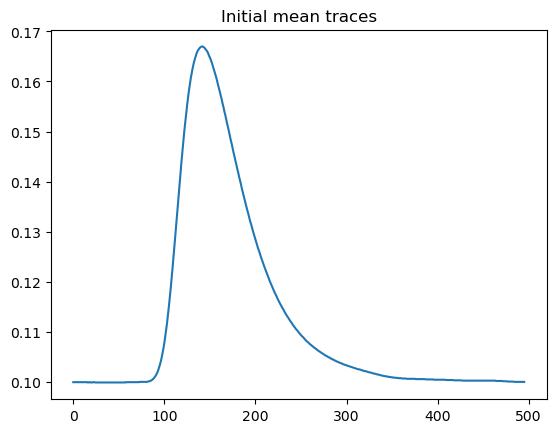

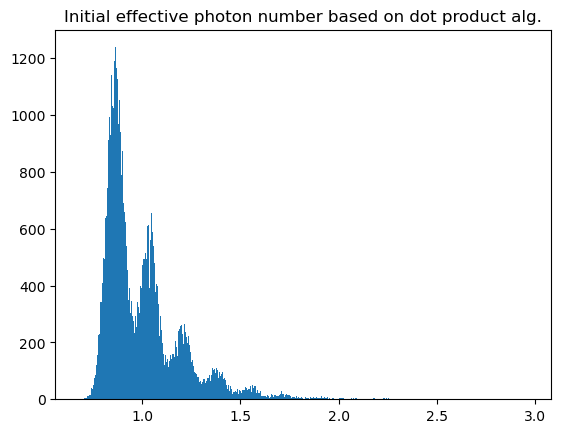

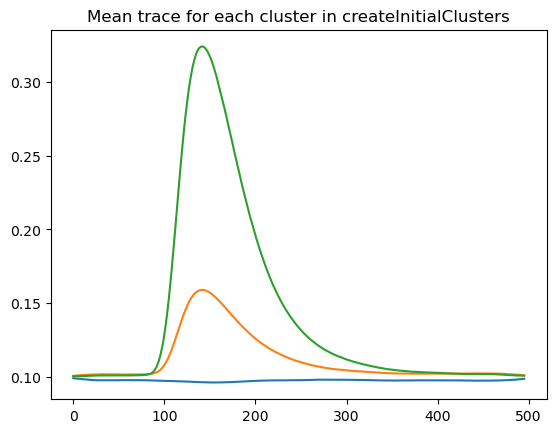

In [30]:
pika = PIKA()

dataset = pika.runPIKA(config)